# Car Breakdown Prediction

In deze notebook bouwen we een machine learning model om te voorspellen of een voertuig binnen de volgende 30 dagen een breakdown zal hebben.

De opdracht bestaat uit:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Train/test split
- Een Random Forest model trainen
- Evaluatie met accuracy en een confusion matrix
- Een geldige Kaggle submission maken

Voor deze toepassing is het belangrijk om echte breakdowns zo goed mogelijk te detecteren. Daarom kijken we niet alleen naar accuracy, maar ook naar false negatives in de confusion matrix.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

train_df = pd.read_csv("train_CarBreakDown.csv")
test_df = pd.read_csv("test_CarBreakDown.csv")

print(train_df.head())
print(train_df.shape)
print(test_df.shape)

     id vehicle_brand  vehicle_age_years     mileage_km  engine_hours  \
0   959        Toyota               20.0  494744.972722   9700.481467   
1   804        Toyota                0.0   38376.684834   1650.726428   
2  1304       Hyundai                1.0  188558.432414   6678.958321   
3   268        Toyota                5.0   92828.113285   2986.923461   
4    47           NaN               10.0  118366.394287   4222.193011   

   last_service_km_ago  oil_quality_pct  avg_trip_length_km weather_exposure  \
0          1672.048445        61.664556           30.362090             high   
1            21.269170        23.370666            2.500801             high   
2         11726.320455        25.491428           41.692205           medium   
3          1845.744691        54.060416            6.464345             high   
4         12551.181627        65.766074           47.159242              low   

  fuel_type  cleanliness_score  driver_satisfaction_score tyre_type  \
0    petr

## Exploratory Data Analysis (EDA)

Voordat we een model trainen bekijken we eerst de dataset.

Machine learning werkt op data, dus het is belangrijk om te controleren:
- welke kolommen er zijn
- of er ontbrekende waarden zijn
- hoe de target verdeeld is


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1050 non-null   int64  
 1   vehicle_brand              1029 non-null   object 
 2   vehicle_age_years          1034 non-null   float64
 3   mileage_km                 1033 non-null   float64
 4   engine_hours               1035 non-null   float64
 5   last_service_km_ago        1040 non-null   float64
 6   oil_quality_pct            1014 non-null   float64
 7   avg_trip_length_km         1038 non-null   float64
 8   weather_exposure           1037 non-null   object 
 9   fuel_type                  1036 non-null   object 
 10  cleanliness_score          995 non-null    float64
 11  driver_satisfaction_score  1037 non-null   float64
 12  tyre_type                  1033 non-null   object 
 13  breakdown_next_30_days     1050 non-null   int64

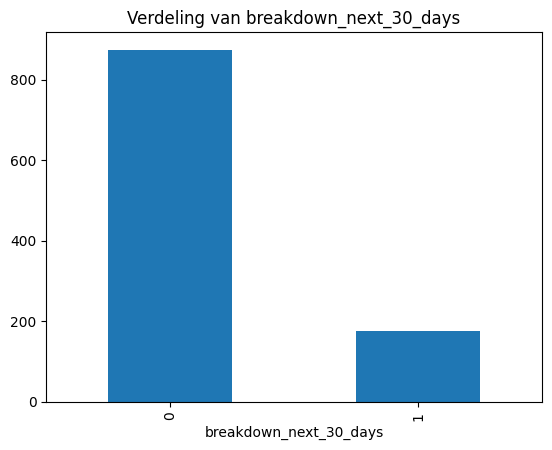

In [ ]:
print(train_df.info())
print(train_df.isnull().sum())
print(train_df.describe(include="all"))

print(train_df["breakdown_next_30_days"].value_counts())

train_df["breakdown_next_30_days"].value_counts().plot(kind="bar")
plt.title("Verdeling van breakdown_next_30_days")
plt.show()

## Features en Target

In machine learning maken we een onderscheid tussen:
- X = features
- y = target

De target in deze dataset is `breakdown_next_30_days`.

De kolom `id` gebruiken we niet om te trainen.


In [ ]:
y = train_df["breakdown_next_30_days"]

X = train_df.drop(columns=[
    "breakdown_next_30_days",
    "id"
])

X_kaggle = test_df.drop(columns=["id"])

## Encoding van categorische variabelen

Sommige kolommen bevatten tekstwaarden.
Machine learning modellen kunnen daar niet rechtstreeks mee werken.

Daarom gebruiken we one-hot encoding om categorische kolommen om te zetten naar numerieke kolommen.


In [ ]:
X = pd.get_dummies(X)
X_kaggle = pd.get_dummies(X_kaggle)

X, X_kaggle = X.align(X_kaggle, join="left", axis=1, fill_value=0)

## Train/Test Split

Om het model eerlijk te evalueren splitsen we de data op in:
- een training set
- een test set

We gebruiken 80% van de data om te trainen en 20% om te testen.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(840, 30)
(210, 30)


## Random Forest Model

Als benchmark gebruiken we een Random Forest classifier.

Random Forest is een ensemble methode die meerdere decision trees combineert om voorspellingen te maken.

We verhogen hier het aantal bomen naar 1000. Met 1000 bomen werden minder breakdowns gemist dan met 100 bomen. Een verdere verhoging naar 10000 gaf geen extra verbetering.


In [ ]:
model = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

## Model Evaluatie met aangepaste threshold

Standaard voorspelt een classificatiemodel klasse 1 pas wanneer de kans groot genoeg is.

In deze opdracht is het belangrijk om echte breakdowns zo goed mogelijk te detecteren. Daarom testen we een aangepaste threshold.

Een lagere threshold zorgt ervoor dat het model sneller een breakdown voorspelt. Daardoor daalt meestal het aantal false negatives, maar stijgt ook het aantal false positives.

Na het testen van meerdere waarden kiezen we hier voor een threshold van 0.3, omdat dit een betere balans geeft tussen het detecteren van breakdowns en het vermijden van te veel onnodige waarschuwingen.

In [ ]:
y_proba = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Threshold:", threshold)

Accuracy: 0.7904761904761904
Threshold: 0.3


## Confusion Matrix

Naast accuracy gebruiken we ook een confusion matrix.

Die toont:
- correcte voorspellingen van klasse 0
- correcte voorspellingen van klasse 1
- false positives
- false negatives

Voor deze opdracht zijn false negatives extra belangrijk, omdat dat de gevallen zijn waarin er wel een breakdown gebeurt maar het model geen breakdown voorspelt.


[[155  20]
 [ 24  11]]


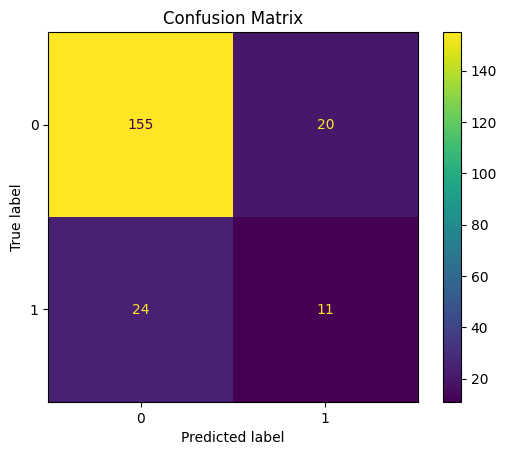

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Interpretatie van de Confusion Matrix

De confusion matrix toont hoeveel voorspellingen correct en fout zijn.

Bij deze toepassing is vooral de onderste linker waarde belangrijk:
- dat zijn de gevallen waar er in werkelijkheid wel een breakdown was
- maar het model toch geen breakdown voorspelde

Dat zijn false negatives, en die willen we zoveel mogelijk beperken.

Een false positive is minder erg, omdat dit meestal alleen leidt tot een extra controle van het voertuig.

In [193]:
false_negatives = cm[1, 0]
false_positives = cm[0, 1]

print("False negatives:", false_negatives)
print("False positives:", false_positives)

False negatives: 24
False positives: 20


## Waarom accuracy minder belangrijk is

In deze toepassing is accuracy niet de belangrijkste maat.

Een belangrijk probleem is wanneer het model een breakdown niet voorspelt terwijl er wel een breakdown zal gebeuren. Dit noemen we een false negative.

In de context van voertuigen kan dit gevaarlijk zijn. Als het model geen probleem voorspelt terwijl er wel een technisch defect zal optreden, kan dit leiden tot een breakdown terwijl iemand met de auto rijdt.

Daarom is het in deze opdracht belangrijk om vooral false negatives te verminderen, zelfs als dit betekent dat het model soms ten onrechte een breakdown voorspelt.


## Keuze van het aantal bomen

We hebben het aantal bomen in het Random Forest verhoogd van 100 naar 1000.

Dit zorgde voor een betere detectie van breakdowns, omdat het model stabielere voorspellingen kon maken.

Toen het aantal bomen verder verhoogd werd naar 10000, verbeterde het resultaat niet verder.

Daarom werd gekozen voor `n_estimators = 1000`, omdat dit een betere balans geeft tussen prestaties en rekentijd.

## Keuze van de threshold

Om het aantal gemiste breakdowns te verminderen hebben we verschillende thresholds getest.

Een hogere threshold zorgt ervoor dat het model bijna nooit een breakdown voorspelt, waardoor echte breakdowns gemist worden.

Een veel te lage threshold zorgt ervoor dat het model bijna altijd een breakdown voorspelt, waardoor er te veel false positives ontstaan.

Threshold 0.3 geeft een betere balans. Het model detecteert meer echte breakdowns dan met de standaard threshold van 0.5, zonder dat het extreem veel false positives produceert.

## Optimalisatie van het model

We hebben verschillende hyperparameters en thresholds getest om het aantal gemiste breakdowns te verminderen.

Een zeer lage threshold kan het aantal false negatives sterk verlagen, maar zorgt ervoor dat het model bijna alle voertuigen als breakdown voorspelt. Hierdoor ontstaat een groot aantal false positives en daalt de accuracy sterk.

Daarom werd gekozen voor een threshold van 0.3. Dit geeft een betere balans tussen het detecteren van echte breakdowns en het vermijden van te veel onterechte waarschuwingen.

Het doel is niet om een perfect model te hebben, maar een model dat een realistische trade-off maakt tussen verschillende soorten fouten.

## Kaggle Submission

Na het trainen van het model maken we voorspellingen voor de testdataset.

Voor de Kaggle submission gebruiken we dezelfde threshold, zodat de evaluatie en de uiteindelijke voorspellingen op dezelfde manier gebeuren.


In [ ]:
kaggle_proba = model.predict_proba(X_kaggle)[:, 1]
kaggle_predictions = (kaggle_proba >= threshold).astype(int)

submission = pd.DataFrame({
    "id": test_df["id"],
    "breakdown_next_30_days": kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

     id  breakdown_next_30_days
0  1356                       0
1   889                       0
2  1190                       0
3   122                       0
4  1101                       0


## Conclusie

In deze notebook hebben we een eerste benchmark model gebouwd met Random Forest.

We hebben:
1. de dataset verkend met EDA
2. de target en features bepaald
3. categorische variabelen encoded
4. de data opgesplitst in train en test
5. een Random Forest model getraind
6. het model geëvalueerd met accuracy en een confusion matrix
7. het aantal bomen verhoogd naar 1000
8. een threshold gekozen die beter omgaat met het detecteren van breakdowns
9. een Kaggle submission gemaakt

Voor deze toepassing is het belangrijker om echte breakdowns te detecteren dan om enkel een hoge accuracy te behalen. Daarom werd naast accuracy ook sterk gekeken naar false negatives in de confusion matrix.

## Gebruik van AI

AI werd gebruikt om hulp te krijgen bij het structureren van de notebook en het opstellen van basiscode voor de minimum requirements van de challenge.

De gebruikte prompt vroeg om een eenvoudige uitwerking met:
- EDA
- Random Forest
- accuracy
- confusion matrix
- Kaggle submission
- een aangepaste threshold om minder echte breakdowns te missen

De code werd nadien nagekeken en aangepast aan de echte kolomnamen van de dataset.
